importing data sets.

In [44]:
!pip install scikit-learn

In [ ]:
#import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
#set theme 
sns.set_theme(style="whitegrid")
#import dataset of confirmed exoplanets
df_confirmed = pd.read_csv("confirmedPlanets.csv",comment ='#', on_bad_lines='skip')
#import dataset of unconfirmed exoplanets
df_unconfirmed=pd.read_csv("unconfirmedPlanets.csv",comment ='#',on_bad_lines='skip')


#Add labels
df_confirmed["label"] = 0 #0 for confirmed
df_unconfirmed["label"] = 1#1 for unconfirmed

#Matches common columns
common_cols = list(set(df_confirmed.columns) & set(df_unconfirmed.columns))
common_cols.append("label")  # Ensure label is included

df_confirmed = df_confirmed[common_cols]
df_unconfirmed = df_unconfirmed[common_cols]

# Combine datasets
df_both = pd.concat([df_confirmed, df_unconfirmed], ignore_index=True)

#Separate numeric and categorical columns after combining
numeric_cols = df_both.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_cols = df_both.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != "label"]

# Fill missing values. Median for numerical and mode for categorical
for col in numeric_cols:
    df_both[col] = df_both[col].fillna(df_both[col].median())
for col in categorical_cols:
    df_both[col] = df_both[col].fillna(df_both[col].mode()[0])

# Encode categorical variables
df_all = pd.get_dummies(df_both, columns=categorical_cols)

# Separate features and target
X = df_all.drop("label", axis=1)
y = df_all["label"]

print("label" in df_all.columns)  # Should print True
print(df_all.shape)

True
(47450, 18)


In [ ]:
df.shape

(39537, 47)

In [ ]:
#Exploration of data
df.head()
df.info()
df.shape
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 39537 entries, 0 to 39536
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39537 non-null  str    
 1   hostname         39537 non-null  str    
 2   default_flag     39537 non-null  int64  
 3   sy_snum          39537 non-null  int64  
 4   sy_pnum          39537 non-null  int64  
 5   discoverymethod  39537 non-null  str    
 6   disc_year        39535 non-null  float64
 7   disc_facility    39537 non-null  str    
 8   soltype          39537 non-null  str    
 9   pl_controv_flag  39537 non-null  int64  
 10  pl_orbper        36204 non-null  float64
 11  pl_orbpererr1    34501 non-null  float64
 12  pl_orbpererr2    34500 non-null  float64
 13  pl_orbperlim     36204 non-null  float64
 14  pl_rade          27208 non-null  float64
 15  pl_radeerr1      26466 non-null  float64
 16  pl_radeerr2      26466 non-null  float64
 17  pl_radelim       29953 

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2',
       'pl_orbperlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim',
       'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_orbeccen',
       'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_eqt',
       'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_spectype',
       'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad',
       'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1',
       'st_masserr2', 'st_masslim', 'sy_gaiamag', 'sy_gaiamagerr1',
       'sy_gaiamagerr2'],
      dtype='str')

In [ ]:
#Exploration of data
df.head()
df.info()
df.shape
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 39537 entries, 0 to 39536
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39537 non-null  str    
 1   hostname         39537 non-null  str    
 2   default_flag     39537 non-null  int64  
 3   sy_snum          39537 non-null  int64  
 4   sy_pnum          39537 non-null  int64  
 5   discoverymethod  39537 non-null  str    
 6   disc_year        39535 non-null  float64
 7   disc_facility    39537 non-null  str    
 8   soltype          39537 non-null  str    
 9   pl_controv_flag  39537 non-null  int64  
 10  pl_orbper        36204 non-null  float64
 11  pl_orbpererr1    34501 non-null  float64
 12  pl_orbpererr2    34500 non-null  float64
 13  pl_orbperlim     36204 non-null  float64
 14  pl_rade          27208 non-null  float64
 15  pl_radeerr1      26466 non-null  float64
 16  pl_radeerr2      26466 non-null  float64
 17  pl_radelim       29953 

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2',
       'pl_orbperlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim',
       'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_orbeccen',
       'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_eqt',
       'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_spectype',
       'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad',
       'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1',
       'st_masserr2', 'st_masslim', 'sy_gaiamag', 'sy_gaiamagerr1',
       'sy_gaiamagerr2'],
      dtype='str')

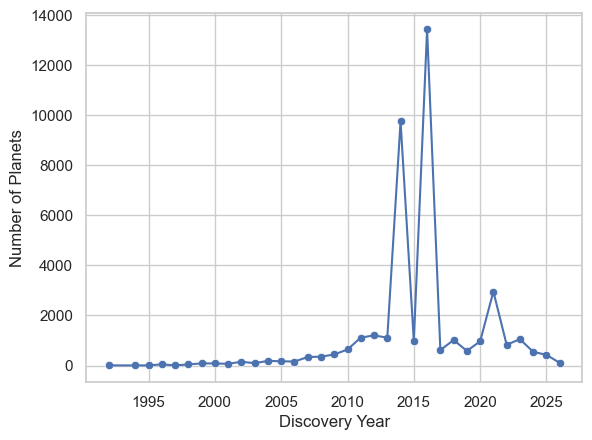

In [ ]:
#create scatterplot that shows the effect the Kepler telescope has
year_counts=df['disc_year'].value_counts().sort_index()
#convert to a dataframe
year_counts= year_counts.reset_index()
year_counts.columns=['disc_year','planet_count']
#create a scatterplot
sns.scatterplot(data=year_counts, x='disc_year',y='planet_count')
plt.title=("Number of Planets and their discovery year")
plt.xlabel('Discovery Year')
plt.ylabel('Number of Planets')
#create a straight line to show the improvement
sns.lineplot(data=year_counts,x='disc_year',y='planet_count')
plt.show()

<class 'str'>
<class 'str'>


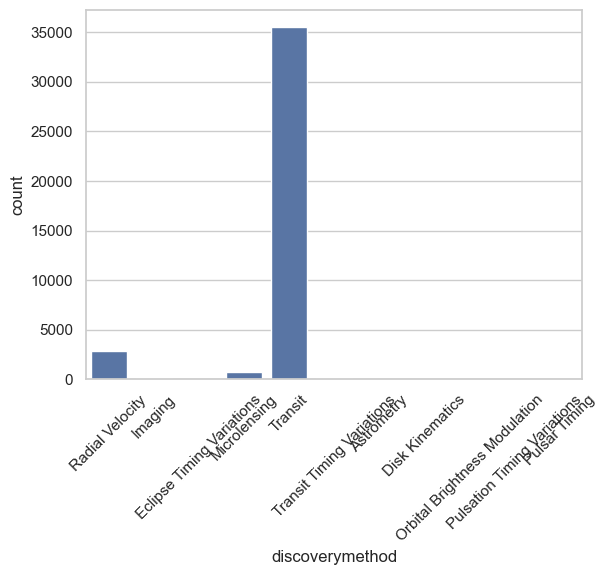

In [ ]:
#histogram showcasing the different types of planets
sns.countplot(data=df,x="discoverymethod")
plt.xticks(rotation=45)
print(type(plt.title))
print(type(plt.title))
plt.show()

In [ ]:
#preparing the data 
#any missing values
#To show any missing values. I'll keep the ones with the lowest score because its the cleanest.
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_pct
})

missing_df

,missing_count,missing_percent
pl_eqterr1,36900,93.330298
pl_eqterr2,36900,93.330298
st_spectype,36532,92.399524
pl_orbeccenerr2,35674,90.229405
pl_orbeccenerr1,35673,90.226876
pl_eqt,22185,56.111996
pl_orbeccen,20637,52.196677
pl_eqtlim,19442,49.174191
pl_orbeccenlim,17894,45.258871
pl_radeerr2,13071,33.060171


In [ ]:
df_both = pd.get_dummies(df_both, columns=categorical_cols)

In [ ]:
print(df_both.columns)

Index(['st_radlim', 'pl_radeerr2', 'st_raderr1', 'pl_orbper', 'st_rad',
       'st_teff', 'st_tefferr1', 'st_tefferr2', 'pl_radeerr1', 'pl_rade',
       'st_raderr2', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_radelim',
       'pl_orbperlim', 'st_tefflim'],
      dtype='str')


In [ ]:
print("label" in df_both.columns)  # Should print True
df_both.head()

False


,st_radlim,pl_radeerr2,st_raderr1,pl_orbper,st_rad,st_teff,st_tefferr1,st_tefferr2,pl_radeerr1,pl_rade,st_raderr2,pl_orbpererr1,pl_orbpererr2,pl_radelim,pl_orbperlim,st_tefflim
0,0.0,-0.27,2.85,323.21000,13.76,4874.0,122.0,-122.0,0.45,2.6,-2.450000,0.060000,-0.050000,0.0,0.0,0.0
1,0.0,-0.27,2.00,326.03000,19.00,4742.0,100.0,-100.0,0.45,2.6,-2.000000,0.320000,-0.320000,0.0,0.0,0.0
2,0.0,-0.27,0.07,8.47134,0.98,5639.0,122.0,-122.0,0.45,2.6,-0.061188,0.000035,-0.000035,0.0,0.0,0.0
3,0.0,-0.27,0.07,8.47134,0.98,5639.0,122.0,-122.0,0.45,2.6,-0.061188,0.000035,-0.000035,0.0,0.0,0.0
4,0.0,-0.27,2.84,516.21997,29.79,4213.0,46.0,-46.0,0.45,2.6,-2.840000,3.200000,-3.200000,0.0,0.0,0.0


In [ ]:
X = df_both.drop("label", axis=1)
y = df_both["label"]

KeyError: "['label'] not found in axis"

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
# Select only unconfirmed planets
X_unconfirmed = df_both[df_both["label"] == 1].drop("label", axis=1)

# Predict probability of being "confirmed"
probs = model.predict_proba(X_unconfirmed)[:, 0]  # probability of label 0 (confirmed)

# Add probabilities to unconfirmed planets
df_unconfirmed["prob_confirmed"] = probs

# Show top 10 most likely real planets
df_unconfirmed.sort_values("prob_confirmed", ascending=False).head(10)

KeyError: "['label'] not found in axis"

In [ ]:
!pip install scikit-learn

In [ ]:
#drop value with too high of missing_count
df_clean=df.drop(columns=["pl_eqterr1","pl_eqterr2", "st_spectype","pl_orbeccenerr2",
                          "pl_orbeccenerr1","pl_eqt","pl_orbeccen","pl_eqtlim",
                          "pl_orbeccenlim","pl_radeerr2","pl_radeerr1","pl_radjerr1",
                          "pl_radjerr2","pl_radj", "pl_rade", "pl_radjlim",
                          "st_masserr2","st_masserr1","pl_radelim", "st_raderr2",
                          "st_raderr1","pl_radj","pl_rade","pl_radjlim",
                          "st_masserr2","st_masserr1","pl_radelim","st_raderr2",
                          "st_raderr1","st_mass","st_masslim","pl_orbpererr2",
                          "pl_orbpererr1","st_tefferr2", "st_tefferr1","st_tefflim"])
#copy dataset
df_model=df_clean.copy()
#fill in numeric columns with median because they are numeric numbers
num_cols = ["st_teff", "st_rad", "pl_orbper", "sy_gaiamag"]

for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

#fill in categorical columns
df_model["discoverymethod"] = df_model["discoverymethod"].fillna(df_model["discoverymethod"].mode()[0])
df_model["disc_facility"] = df_model["disc_facility"].fillna(df_model["disc_facility"].mode()[0])

#convert text to numbers because models can only read numerical values
df_model = pd.get_dummies(df_model, columns=["discoverymethod", "disc_facility"])

#Because we are using large values, we will use Log transform
df_model["pl_orbper"] = np.log1p(df_model["pl_orbper"])


